# Урок 3. kNN

В уроке мы разобрали построение модели kNN на базовом наборе данных Iris. Для лучшего понимания, как работает алгоритм, мы использовали только два признака - длину и ширину лепестка.

Однако другие признаки тоже могли быть важны для получения моделью более детальной информации об объектах и, соответственно, построения более точных прогнозов.

### 1.
Поочередно добавьте к признакам (petal length, petal width) из урока  оставшиеся признаки, чтобы получилось: 1) (sepal length, petal length, petal width); 2) (sepal width, petal length, petal width).

*Примечание: признаки могут быть расположены в любом порядке.*

In [2]:
from sklearn.datasets import load_iris

Напомним порядок расположения признаков в массиве данных

In [3]:
iris_dataset = load_iris()
iris_dataset['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Для формирования массива новых признаков проще воспользоваться не срезами, как мы делали в уроке - iris_dataset.data[:, 2:4] (здесь мы показываем, что выбираем только со 2го по 4й столбец, причем не включая 2й), а просто удалить один из ненужных нам столбцов с помощью функции библиотеки *numpy.delete*

**Пример**

In [14]:
# В Jupyter выполните эту команду чтобы сменить рабочую директорию
import os
os.chdir('C:/Users/user0907')
#os.chdir('C:\TanderAPI')

In [4]:
import numpy as np

In [21]:
a = np.array([[ 0,  1,  2,  3],
               [ 4,  5,  6,  7],
               [ 8,  9, 10, 11],
               [12, 13, 14, 15]])

a_new = np.delete(a, 0, axis=1)
a_new

array([[ 1,  2,  3],
       [ 5,  6,  7],
       [ 9, 10, 11],
       [13, 14, 15]])

In [5]:
from sklearn.model_selection import train_test_split
iris_dataset = load_iris()



In [6]:
iris_dataset_1 = np.delete(iris_dataset.data, 0, axis=1)
iris_dataset_2 = np.delete(iris_dataset.data, 1, axis=1)

### 2.
Теперь посмотрите на трехмерном графике, насколько хорошо данные разделяются по каждой из совокупностей трех параметров.

In [7]:


from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

**Пример** построения трехмерного графика

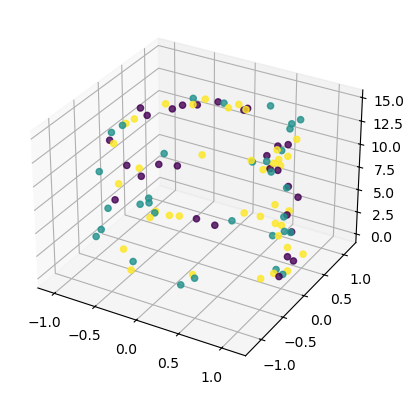

In [8]:
ax = plt.axes(projection='3d')

zdata = 15 * np.random.random(100) # точки оси Z
xdata = np.sin(zdata) + 0.1 * np.random.randn(100) # точки оси X
ydata = np.cos(zdata) + 0.1 * np.random.randn(100) # точки оси Y
colors = np.random.randint(3, size=100)

ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

**Примечание: для установки цвета в функции используйте *c=iris_dataset.target*.**

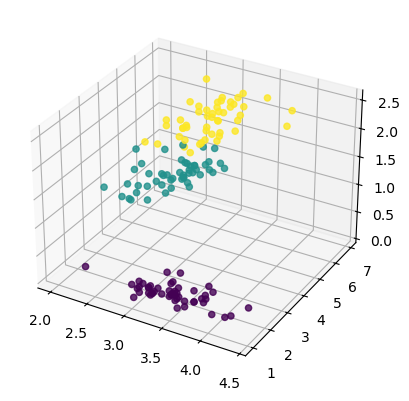

In [9]:
ax = plt.axes(projection='3d')


iris_dataset_1 = np.delete(iris_dataset.data, 0, axis=1)
#iris_dataset_2 = np.delete(iris_dataset.data, 1, axis=1)
x_train, x_test, y_train, y_test = train_test_split(
    iris_dataset_1[:, 1:3],  # берем столбцы 1 и 2 (petal length и petal width)
    iris_dataset.target,      # метки классов
    random_state=0
)
xdata = iris_dataset_1[:, 0]  # первый столбец (sepal width)
ydata = iris_dataset_1[:, 1]  # второй столбец (petal length)
zdata = iris_dataset_1[:, 2]  # третий столбец (petal width)
colors = iris_dataset.target

ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

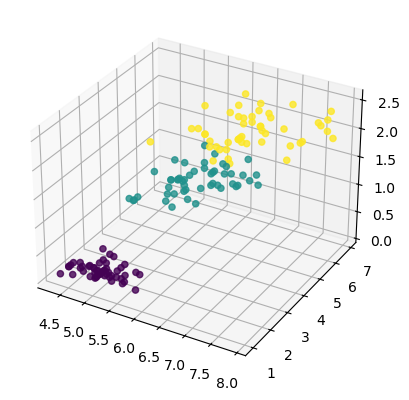

In [10]:
ax = plt.axes(projection='3d')


#iris_dataset_1 = np.delete(iris_dataset.data, 0, axis=1)
iris_dataset_2 = np.delete(iris_dataset.data, 1, axis=1)
x_train, x_test, y_train, y_test = train_test_split(
    iris_dataset_2[:, 1:3],  # берем столбцы 1 и 2 (petal length и petal width)
    iris_dataset.target,      # метки классов
    random_state=0
)
xdata = iris_dataset_2[:, 0]  # первый столбец (sepal width)
ydata = iris_dataset_2[:, 1]  # второй столбец (petal length)
zdata = iris_dataset_2[:, 2]  # третий столбец (petal width)
colors = iris_dataset.target

ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

### 3.
С помощью функции sklearn.model_selection.train_test_split разделите данные на тренировочный и тестовый датасеты и затем, применив библиотечную версию алгоритма sklearn.neighbors.KNeighborsClassifier, постройте модель для наборов данных *iris_dataset_1* и *iris_dataset_2* (по умолчанию используйте n_neighbors=5).

*Примечание: в функции train_test_split используйте параметр random_state=17 для воспроизводимости результатов.*

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [12]:

x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(iris_dataset_1, 
                                                    iris_dataset['target'],
                                                    random_state=0) # random_state - для воспроизводимости
print(f'X_train_1 shape: {x_train_1.shape}, y_train_1 shape: {y_train_1.shape},\n'
      f'X_test_1 shape: {x_test_1.shape}, y_test_1 shape: {y_test_1.shape}')


x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(iris_dataset_2, 
                                                    iris_dataset['target'],
                                                    random_state=0) # random_state - для воспроизводимости
print(f'X_train_2 shape: {x_train_2.shape}, y_train_2 shape: {y_train_2.shape},\n'
      f'X_test_2 shape: {x_test_2.shape}, y_test_2 shape: {y_test_2.shape}')



X_train_1 shape: (112, 3), y_train_1 shape: (112,),
X_test_1 shape: (38, 3), y_test_1 shape: (38,)
X_train_2 shape: (112, 3), y_train_2 shape: (112,),
X_test_2 shape: (38, 3), y_test_2 shape: (38,)


### 4.
Проверьте точность работы обеих моделей, используя встроенную функцию sklearn.metrics.accuracy_score. Сравните результат их работы с результатом, полученным на наборе данных с двумя признаками (который разбирался в уроке), и укажите ответ.

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn_model_1 = knn.fit(x_train_1, y_train_1)
knn_model_2 = knn.fit(x_train_2, y_train_2)
knn_predictions_1 = knn.predict(x_test_1)
knn_predictions_2 = knn.predict(x_test_2)

In [15]:
accuracy_1 = accuracy_score(y_test_1, knn_predictions_1)
accuracy_2 = accuracy_score(y_test_2, knn_predictions_2)

print(f'Accuracy_1: {accuracy_1}, accuracy_2: {accuracy_2}')
#вывод: добавление признаков - ухудшило точность предсказаний

Accuracy_1: 0.9210526315789473, accuracy_2: 0.9736842105263158


### 5.
Постройте модель на данных *x_train_1, y_train_1* с гиперпараметром n_neighbors, пробегающим значения от 1 до 20 включительно, и укажите значения n_neighbors, которым соответствует наиболее высокий результат функции accuracy_score().

*Примечание: можно воспользоваться циклом for, чтобы не прописывать вручную все 20 вариаций модели.*

In [18]:
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn_model_1 = knn.fit(x_train_1, y_train_1)
    knn_model_2 = knn.fit(x_train_2, y_train_2)
    knn_predictions_1 = knn.predict(x_test_1)
    knn_predictions_2 = knn.predict(x_test_2)
    accuracy_1 = accuracy_score(y_test_1, knn_predictions_1)
    accuracy_2 = accuracy_score(y_test_2, knn_predictions_2)
    
    print(f'#{i}: Accuracy_1: {accuracy_1}, accuracy_2: {accuracy_2}')
#вывод: максимальная точность предсказаний достигается при количестве ближайших соседей от 3 до 6

#1: Accuracy_1: 0.631578947368421, accuracy_2: 0.9736842105263158
#2: Accuracy_1: 0.8947368421052632, accuracy_2: 0.9736842105263158
#3: Accuracy_1: 0.9210526315789473, accuracy_2: 0.9736842105263158
#4: Accuracy_1: 0.9210526315789473, accuracy_2: 0.9736842105263158
#5: Accuracy_1: 0.9210526315789473, accuracy_2: 0.9736842105263158
#6: Accuracy_1: 0.9210526315789473, accuracy_2: 0.9473684210526315
#7: Accuracy_1: 0.8947368421052632, accuracy_2: 0.9473684210526315
#8: Accuracy_1: 0.8421052631578947, accuracy_2: 0.9473684210526315
#9: Accuracy_1: 0.8421052631578947, accuracy_2: 0.9736842105263158
#10: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9473684210526315
#11: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9736842105263158
#12: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9473684210526315
#13: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9736842105263158
#14: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9736842105263158
#15: Accuracy_1: 0.7894736842105263, accuracy_2: 0.9736842